# Import libraries

In [2]:
import torch
import torch.nn as nn

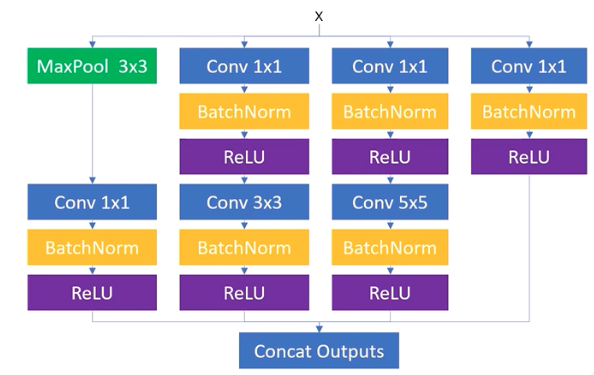

# Model architectures

In [21]:
class ImageClassificationInception(nn.Module):
    def __init__(self, in_channels = 1, out_channels=4) -> None: #input channels = 1 (grayscale), output channels = 4 (number of classes)
        super().__init__()

        # 1x1 convolution branch (branch 4 - the right hand side)
        self.branch1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels //4, kernel_size =1),
            nn.BatchNorm2d(out_channels //4),
            nn.ReLU()
        )

        # 3x3 convolution branch (branch 2 - the middle left)
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels //4, kernel_size =1),
            nn.BatchNorm2d(out_channels //4),
            nn.ReLU(),
            nn.Conv2d(out_channels //4, out_channels //4, kernel_size = 3, padding=1),
            nn.BatchNorm2d(out_channels //4),
            nn.ReLU(),
        )

        # 5x5 convolution branch (branch 3 - the middle right)
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels //4, kernel_size =1),
            nn.BatchNorm2d(out_channels //4),
            nn.ReLU(),
            nn.Conv2d(out_channels //4, out_channels //4, kernel_size =5, padding=2), #padding=2 outer rows and columns
            nn.BatchNorm2d(out_channels //4),
            nn.ReLU(),
        ) 

        # Max pooling branch 
        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_channels //4, kernel_size =1),
            nn.BatchNorm2d(out_channels //4),
            nn.ReLU(),
        )

    def forward(self, x):
        out1x1 = self.branch1x1(x)
        out3x3 = self.branch3x3(x)
        out5x5 = self.branch3x3(x)
        out_pool = self.branch_pool(x)
        out = torch.cat((out1x1, out3x3, out5x5, out_pool), dim=1) #concat along channel dimension
        out = torch.flatten(out,1)
        out = nn.Linear(out.shape[1], 10)(out)  # Assuming 10 classes for classification
        out = nn.Sigmoid()(out)
        return out
           

In [ ]:
# Test model
input = torch.rand(4 ,1, 32, 32)
model = ImageClassificationInception(in_channels=1, out_channels=128)
model(input).shape 

torch.Size([4, 10])